# Error Analysis

**CONFUSION MATRIX · FALSE NEGATIVES · FALSE POSITIVES**

---

## Content

- [1 · Setup](#1-setup)
- [2 · Recap — the winner at the tuned threshold](#2-recap-the-winner-at-the-tuned-threshold)
- [3 · Confusion matrix](#3-confusion-matrix)
- [4 · False negatives — the missed bad buys](#4-false-negatives-the-missed-bad-buys)
- [5 · False positives — the wrongly flagged good cars](#5-false-positives-the-wrongly-flagged-good-cars)
- [6 · How the champion was found](#6-how-the-champion-was-found)
- [7 · Conclusion](#7-conclusion)

This notebook goes one level deeper than the headline F1 in `04_evaluation.ipynb`: instead of
asking *how well* the champion scores, it asks *which* cars it gets wrong, and why. For a triage
filter that decides which vehicles a human reviews, that's the actionable part.

**Input:** `data/02_interim/` (same held-out test split as `04_evaluation`) · **Output:**
`public/img/confusion_matrix.png`.

## 1 · Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, io, contextlib
import matplotlib.pyplot as plt
from us_used_vehicle_resales.cleaning import clean_data
from us_used_vehicle_resales.features import engineer_features
from us_used_vehicle_resales.config_features_catalog import features_catalog
from us_used_vehicle_resales.config_models_catalog import models_catalog
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay)

INT='../data/02_interim/'; IMG='../public/img/'
pd.options.display.float_format='{:.4f}'.format

def _quiet(fn,*a,**k):
    with contextlib.redirect_stdout(io.StringIO()): return fn(*a,**k)

def load_prep(name):
    X=pd.read_parquet(f'{INT}features_{name}.parquet')
    y=pd.read_parquet(f'{INT}target_{name}.parquet').iloc[:,0]
    Xf=_quiet(engineer_features,_quiet(clean_data,X),print_status=False)
    return Xf, y.loc[Xf.index]

X_train,y_train=load_prep('train')
X_test, y_test =load_prep('test')
print(f'Train {X_train.shape}  bad-buy {y_train.mean():.2%}')
print(f'Test  {X_test.shape}  bad-buy {y_test.mean():.2%}')

Train (52496, 41)  bad-buy 12.35%
Test  (13124, 41)  bad-buy 12.35%


## 2 · Recap — the winner at the tuned threshold

Same model, same test set, same tuned threshold as `04_evaluation.ipynb` — retrained here so
this notebook is self-contained.

In [2]:
feats=[f for f in features_catalog['all_in_with_noise'] if f in X_train.columns]
num=[f for f in feats if str(X_train[f].dtype).startswith(('int','float'))]
cat=[f for f in feats if f not in num]
pre=ColumnTransformer([('num',StandardScaler(),num),
                       ('cat',OneHotEncoder(handle_unknown='ignore'),cat)])
pipe=Pipeline([('pre',pre),('clf',models_catalog['log_reg_lasso'])])
pipe.fit(X_train[feats],y_train)
proba=pipe.predict_proba(X_test[feats])[:,1]

ths=np.linspace(0.2,0.85,66)
f1s=[f1_score(y_test,(proba>=t).astype(int)) for t in ths]
best_t=float(ths[int(np.argmax(f1s))])
pred=(proba>=best_t).astype(int)
print(f'Tuned threshold {best_t:.2f} -> F1 {f1_score(y_test,pred):.4f} '
      f'| Precision {precision_score(y_test,pred):.4f} | Recall {recall_score(y_test,pred):.4f}')

Tuned threshold 0.65 -> F1 0.4227 | Precision 0.4525 | Recall 0.3967


## 3 · Confusion matrix

At the tuned threshold, how many of each type — and what does that mean for the triage workflow?

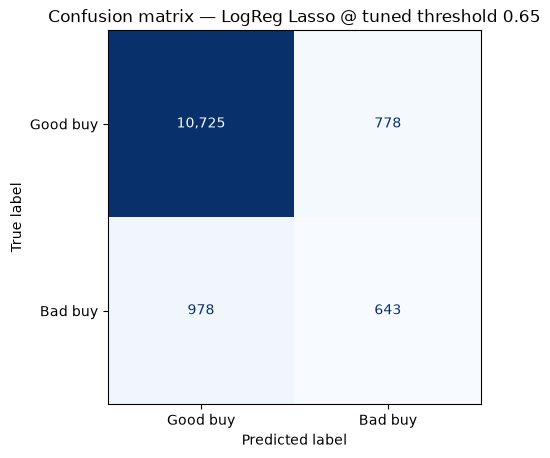

TN 10,725   FP 778
FN 978   TP 643
Of 1,621 real bad buys: 643 caught (39.7%), 978 missed (60.3%)
Of 11,503 real good buys: 778 wrongly flagged for review (6.8%)


In [3]:
cm=confusion_matrix(y_test,pred)
tn,fp,fn,tp=cm.ravel()

disp=ConfusionMatrixDisplay(cm,display_labels=['Good buy','Bad buy'])
fig,ax=plt.subplots(figsize=(5,5))
disp.plot(ax=ax,cmap='Blues',values_format=',d',colorbar=False)
ax.set_title(f'Confusion matrix — LogReg Lasso @ tuned threshold {best_t:.2f}')
plt.tight_layout()
plt.savefig(f'{IMG}confusion_matrix.png',dpi=140,bbox_inches='tight')
plt.show()

n_bad=y_test.sum(); n_good=len(y_test)-n_bad
print(f'TN {tn:,}   FP {fp:,}')
print(f'FN {fn:,}   TP {tp:,}')
print(f'Of {n_bad:,} real bad buys: {tp:,} caught ({tp/n_bad:.1%}), {fn:,} missed ({fn/n_bad:.1%})')
print(f'Of {n_good:,} real good buys: {fp:,} wrongly flagged for review ({fp/n_good:.1%})')

## 4 · False negatives — the missed bad buys

Recall is ~0.40 at the tuned threshold — roughly 6 in 10 bad buys slip through. Are the missed
ones just noise, or do they look systematically different from the ones the model *does* catch?

In [4]:
mask_bad = y_test == 1
fn_mask = mask_bad & (pred == 0)
tp_mask = mask_bad & (pred == 1)

seg_cols = ['VehBCost', 'VehicleAge', 'VehOdo']
comp = pd.DataFrame({
    'Missed (FN)': X_test.loc[fn_mask, seg_cols].mean(),
    'Caught (TP)': X_test.loc[tp_mask, seg_cols].mean(),
})
comp['Gap'] = comp['Missed (FN)'] - comp['Caught (TP)']
comp

,Missed (FN),Caught (TP),Gap
VehBCost,6472.4826,5800.5591,671.9235
VehicleAge,4.6053,5.4681,-0.8628
VehOdo,73167.2147,76747.2208,-3580.0061


In [5]:
wheel = pd.DataFrame({
    'Missed (FN)': X_test.loc[fn_mask, 'WheelType'].value_counts(normalize=True),
    'Caught (TP)': X_test.loc[tp_mask, 'WheelType'].value_counts(normalize=True),
}).fillna(0)
wheel

,Missed (FN),Caught (TP)
WheelType,,
Alloy,0.5573,0.2566
Covers,0.4294,0.1089
Special,0.0123,0.0062
Unknown,0.0010,0.6283


**Finding:** the model's single strongest signal — `WheelType = Unknown` — is present in
**~63 % of caught bad buys** but almost **never** (~0.1 %) in the missed ones. The missed bad buys
look like ordinary cars on this feature (mostly `Alloy`/`Covers` wheels) and are also, on average,
**more expensive (+$672) and newer (+0.9 years)** than the caught ones. In other words: the model
is very good at catching the *"the auction house never even logged the wheel type"* kind of lemon,
but has no comparably strong signal for a **pricier, newer car that turns out to be a bad buy
despite looking clean on paper** — those are the ones that slip through.

## 5 · False positives — the wrongly flagged good cars

At precision ≈ 0.45, more than half of flagged cars are actually good buys sent to review for
nothing. What do *they* look like?

In [6]:
fp_mask = (y_test == 0) & (pred == 1)
tn_mask = (y_test == 0) & (pred == 0)

comp_fp = pd.DataFrame({
    'Flagged (FP)': X_test.loc[fp_mask, seg_cols].mean(),
    'Passed (TN)': X_test.loc[tn_mask, seg_cols].mean(),
})
comp_fp['Gap'] = comp_fp['Flagged (FP)'] - comp_fp['Passed (TN)']
comp_fp

,Flagged (FP),Passed (TN),Gap
VehBCost,5184.9242,6924.4839,-1739.5597
VehicleAge,6.2301,3.9047,2.3254
VehOdo,80893.1620,70401.2530,10491.9090


**Finding:** wrongly flagged good cars are **cheaper (-$1,740) and older (+2.3 years)** than
correctly passed ones — the model is trading a well-known signal (older, lower-value stock skews
risky) against the noise in a 12 % base rate. This is the expected cost of a **high-recall triage
filter**: it over-flags older, cheaper stock. For the business this means the review queue skews
toward lower-value vehicles — worth knowing when sizing the human-review capacity, since those
cars are cheap to double-check individually.

## 6 · How the champion was found

This model wasn't hand-picked — it surfaced from a **systematic sweep** over feature sets ×
model families, logged run-by-run by a self-built **`ModelTracker`** against a **feature catalog**
and a **model catalog** (`config_features_catalog.py` / `config_models_catalog.py`). That
infrastructure — 448 logged runs, best-run flagging, smart model export — is demonstrated in
[`05_experiment_framework.ipynb`](05_experiment_framework.ipynb). It's what made a *fast, repeatable*
comparison possible instead of ad-hoc, one-off training runs.

## 7 · Conclusion

- The confusion matrix confirms the trade-off already visible in the F1/precision/recall
  numbers: **more good cars get flagged than bad ones get missed**, by design of a recall-leaning
  triage filter.
- **Missed bad buys** are the model's real blind spot: newer, pricier cars that don't carry the
  `WheelType = Unknown` data-quality flag. A production version should look for a *second*
  independent risk signal to catch this segment — right now the model leans hard on one feature.
- **Wrongly flagged good cars** skew cheap and older — an acceptable cost for a triage filter,
  since those units are inexpensive to double-check manually.
- **Recommendation:** keep `WheelType = Unknown` as a first-order intake flag (as already stated
  in `04_evaluation.ipynb`), but treat it as necessary, not sufficient — pair it with a second
  feature (e.g. price-vs-market-anchor deviation) specifically to catch the newer/pricier blind
  spot identified here. Full write-up and recommendations →
  [`07_results.ipynb`](07_results.ipynb).